In [1]:
import pandas as pd
pd.__version__

'2.3.2'

## **Exploratory Data Analysis**

#### **Loading Dataset** 

In [46]:
data = pd.read_csv("/Users/subhajyotihalder/SmartPhone Addiction Prediction System/teen_phone_addiction_dataset.csv")
print(data.head())

   ID               Name  Age  Gender          Location School_Grade  \
0   1    Shannon Francis   13  Female        Hansonfort          9th   
1   2    Scott Rodriguez   17  Female      Theodorefort          7th   
2   3        Adrian Knox   13   Other       Lindseystad         11th   
3   4  Brittany Hamilton   18  Female      West Anthony         12th   
4   5       Steven Smith   14   Other  Port Lindsaystad          9th   

   Daily_Usage_Hours  Sleep_Hours  Academic_Performance  Social_Interactions  \
0                4.0          6.1                    78                    5   
1                5.5          6.5                    70                    5   
2                5.8          5.5                    93                    8   
3                3.1          3.9                    78                    8   
4                2.5          6.7                    56                    4   

   ...  Screen_Time_Before_Bed  Phone_Checks_Per_Day  Apps_Used_Daily  \
0  ...       

#### **Droping Non-Informating Columns**

In [47]:
data = data.drop(columns=["ID", "Name","Gender","Location","School_Grade","Parental_Control","Phone_Usage_Purpose"])

print(data.shape)
data.head()

(3000, 18)


,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,4.0,6.1,78,5,0.1,10,3,8,1.4,86,19,3.6,1.7,1.2,4,8.7,10.0
1,17,5.5,6.5,70,5,0.0,3,7,3,0.9,96,9,1.1,4.0,1.8,2,5.3,10.0
2,13,5.8,5.5,93,8,0.8,2,3,10,0.5,137,8,0.3,1.5,0.4,6,5.7,9.2
3,18,3.1,3.9,78,8,1.6,9,10,3,1.4,128,7,3.1,1.6,0.8,8,3.0,9.8
4,14,2.5,6.7,56,4,1.1,1,5,1,1.0,96,20,2.6,0.9,1.1,10,3.7,8.6


#### **Converting Addiction_levels into Categories**

Here , we are converting Addiction_Level into Low / Moderate / High categories. 
We did this because predicting clear addiction levels (Low, Moderate, High) is more useful and reliable than predicting many exact numbers. The original addiction score had too many unique values, some appearing only once, which makes machine learning models unstable and hard to evaluate. By grouping scores into a few meaningful categories, the model becomes easier to train, easier to explain, and more practical for real-world use—like mental health apps or parental controls—where decisions are based on risk levels, not precise decimals

Our Dataset Is NOT a Classification Dataset (Yet)
In the raw data:
Addiction_Level had ~80 unique values
Some values appeared only once
This caused:
Stratified split failure
Severe class imbalance
Meaningless confusion matrices

#### **Spliting Features & Target**

In [55]:
X = data.drop(columns=["Addiction_Level"])
y = data["Addiction_Level"]


In [54]:
y

0       10.0
1       10.0
2        9.2
3        9.8
4        8.6
        ... 
2995     9.8
2996     5.5
2997     6.2
2998    10.0
2999     6.3
Name: Addiction_Level, Length: 3000, dtype: float64

#### **Identifing Numerical & Categorical Columns**

In [50]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


Numerical columns: ['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours']
Categorical columns: []


#### **Standerdising the numerical columns**

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = Pipeline(steps=[
    ("scaler", StandardScaler())
])


#### **Train–Test Split**

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)


(2400, 17) (600, 17)


#### **Applying Preprocessing**

In [59]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)


Train shape: (2400, 17)
Test shape: (600, 17)


In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))



R² Score: 0.7366238141137617


In [63]:
sample_user = X_train.iloc[[0]].copy()

sample_user["Age"] = 16
sample_user["Daily_Usage_Hours"] = 8
sample_user["Sleep_Hours"] = 5
sample_user["Academic_Performance"] = 60
sample_user["Social_Interactions"] = 2
sample_user["Exercise_Hours"] = 0.5
sample_user["Anxiety_Level"] = 8
sample_user["Depression_Level"] = 7
sample_user["Self_Esteem"] = 3
sample_user["Screen_Time_Before_Bed"] = 3
sample_user["Phone_Checks_Per_Day"] = 120
sample_user["Apps_Used_Daily"] = 25
sample_user["Time_on_Social_Media"] = 4
sample_user["Time_on_Gaming"] = 2
sample_user["Time_on_Education"] = 0.5
sample_user["Family_Communication"] = 3
sample_user["Weekend_Usage_Hours"] = 9

prediction = model.predict(sample_user)
print("Predicted Addiction Level:", prediction[0])


Predicted Addiction Level: 13.380397517336721


In [69]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


In [ ]:
xgb_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])



In [71]:
xgb_model.fit(X_train, y_train)



,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None


In [73]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = xgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)



RMSE: 0.4069647550909163
R² Score: 0.9342597377629289


In [74]:
pred = xgb_model.predict(sample_user)[0]
pred = np.clip(pred, 0, 10)

print("Predicted Addiction Level:", pred)



Predicted Addiction Level: 9.773862838745117


In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Gradient Boosting
importances = xgb_model.named_steps["regressor"].feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))


                   Feature  Importance
1        Daily_Usage_Hours    0.271930
11         Apps_Used_Daily    0.177936
12    Time_on_Social_Media    0.138553
13          Time_on_Gaming    0.136432
10    Phone_Checks_Per_Day    0.091067
2              Sleep_Hours    0.069999
5           Exercise_Hours    0.012700
9   Screen_Time_Before_Bed    0.012649
7         Depression_Level    0.012309
4      Social_Interactions    0.012271


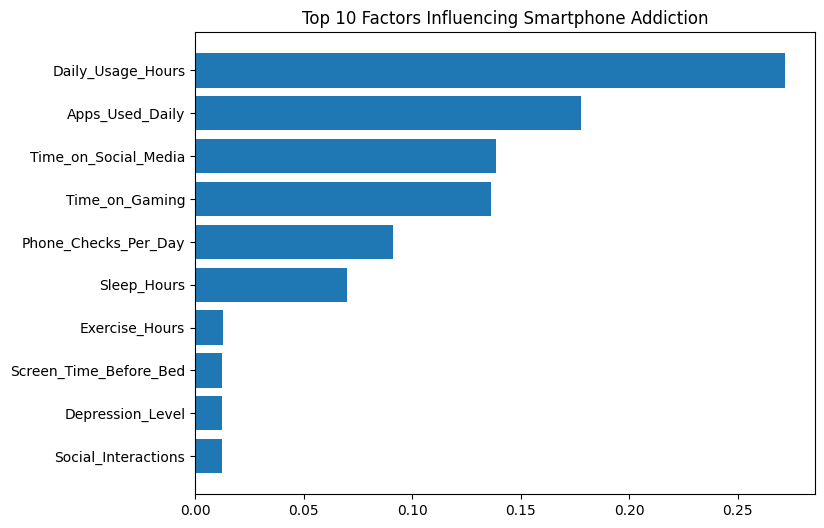

In [76]:
plt.figure(figsize=(8,6))
plt.barh(
    importance_df["Feature"].head(10),
    importance_df["Importance"].head(10)
)
plt.gca().invert_yaxis()
plt.title("Top 10 Factors Influencing Smartphone Addiction")
plt.show()



In [77]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_rmse = cross_val_score(
    xgb_model,
    X,
    y,
    scoring="neg_mean_squared_error",
    cv=5
)

cv_rmse = np.sqrt(-cv_rmse)

print("CV RMSE Mean:", cv_rmse.mean())
print("CV RMSE Std:", cv_rmse.std())


CV RMSE Mean: 0.4100276600862055
CV RMSE Std: 0.012857062707038996


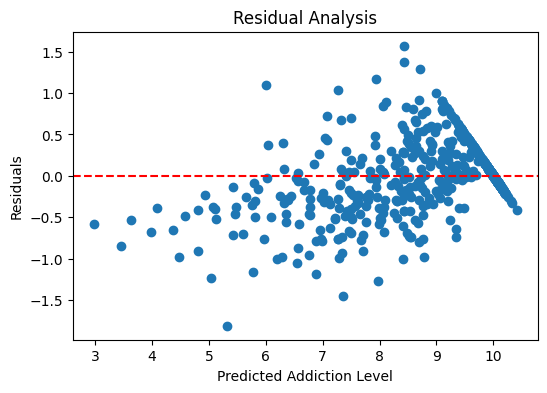

In [78]:
y_pred = xgb_model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Addiction Level")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()




In [79]:
def addiction_risk(score):
    if score < 4:
        return "Low"
    elif score < 7:
        return "Moderate"
    else:
        return "High"

score = np.clip(xgb_model.predict(sample_user)[0], 0, 10)
risk = addiction_risk(score)

print("Predicted Score:", score)
print("Risk Level:", risk)


Predicted Score: 9.773862838745117
Risk Level: High


### **Data Testing**

In [80]:
import pandas as pd
import numpy as np

def test_profile(values, label):
    user = pd.DataFrame([values], columns=X.columns)
    score = xgb_model.predict(user)[0]
    score = np.clip(score, 0, 10)

    if score < 4:
        risk = "Low"
    elif score < 7:
        risk = "Moderate"
    else:
        risk = "High"

    print(f"\n{label}")
    print("Predicted Score:", round(score, 2))
    print("Risk Level:", risk)


#### Test Case 1

In [81]:
low_addiction = [
    16,   # Age
    1.5,  # Daily_Usage_Hours
    8.2,  # Sleep_Hours
    88,   # Academic_Performance
    8,    # Social_Interactions
    4.0,  # Exercise_Hours
    1,    # Anxiety_Level
    1,    # Depression_Level
    8,    # Self_Esteem
    0.2,  # Screen_Time_Before_Bed
    25,   # Phone_Checks_Per_Day
    6,    # Apps_Used_Daily
    0.8,  # Time_on_Social_Media
    0.4,  # Time_on_Gaming
    1.5,  # Time_on_Education
    8,    # Family_Communication
    2.5   # Weekend_Usage_Hours
]

test_profile(low_addiction, "LOW ADDICTION PROFILE")



LOW ADDICTION PROFILE
Predicted Score: 2.12
Risk Level: Low


#### Test Case 4

In [82]:
edge_case_1 = [
    18,
    8.5,
    7.8,
    85,
    7,
    3.0,
    2,
    1,
    7,
    1.0,
    90,
    12,
    2.0,
    1.0,
    2.5,
    7,
    6.0
]

test_profile(edge_case_1, "EDGE CASE: HIGH USAGE BUT HEALTHY")



EDGE CASE: HIGH USAGE BUT HEALTHY
Predicted Score: 9.98
Risk Level: High


In [83]:
high_addiction = [
    15,
    9.0,
    4.2,
    55,
    2,
    0.2,
    8,
    7,
    2,
    3.5,
    160,
    28,
    5.0,
    3.5,
    0.3,
    2,
    11.0
]

test_profile(high_addiction, "HIGH ADDICTION PROFILE")



HIGH ADDICTION PROFILE
Predicted Score: 9.65
Risk Level: High
